In [1]:
import requests
import bs4
import re
from time import sleep
import random
import networkx as nx

When you look at a website using a web browser what you see is a rendered view from an HTML code. This graphical version is much easier for us to read, however, it's not trivial to automatize the process of any data retrieval from it. That's why we will use raw HTML form

The first step is to download the content. We can use a request library. Basic usage is very simple.

In [2]:
headers = {
    'User-Agent': 'IRclasses',
}

response = requests.get('https://en.wikipedia.org/wiki/Pozna%C5%84_University_of_Technology', headers=headers)
response.status_code # it's wise to check the status code

200

In [3]:
response.text

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Poznań University of Technology - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-cont

Working with such a string might be problematic. However, HTML is structured and we can benefit from it. The Beautiful Soup package transforms HTML string into a tree form and allows us to query it in a much more efficient and easier way.

In [4]:
parsed = bs4.BeautifulSoup(response.text)
parsed

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>Poznań University of Technology - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-e

Typically text content is stored in a paragraph element denoted with a 'p' tag. We can take a look at the text from all paragraphs.

In [5]:
for p in parsed.select('p'):
    print(p.getText())



Poznań University of Technology, PUT (Polish: Politechnika Poznańska) is a university in Poznań, Poland.[3] Poznań University of Technology is known as one of the best technical universities in Poland. URAP ranked PUT among the top 6% of world universities and Webometrics ranked it at no. 842 in the world by Google citations for the year 2015. In 1995, it became the first Polish university to become a member of the Conference of European Schools for Advanced Engineering Education and Research (CESAER), an organization comprising the best technical universities in Europe. The university is also a member of the Socrates-Erasmus programme for exchange students from all over Europe, promoting advanced engineering and a European dimension. The university is home to many organizations and student circles, and the radio station Afera 98.6 MHz. The university has over 21,000 students and over 1,100 academic staff.

There are nine faculties (since 2020):

Poznan University of Technology (PUT)

## Task1
Implement a function getText(url)
 - download content from a given url
 - transform it using bs
 - return text from all paragraphs

In [6]:
def getText(url):
    """
    Download content from a given URL, parse it with BeautifulSoup,
    and return the concatenated text from all paragraph ('p') elements.
    """
    output = ""
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # Raise exception for bad status codes
        parsed = bs4.BeautifulSoup(response.text, 'html.parser')
        for p in parsed.select('p'):
            output += p.get_text(separator=" ", strip=True) + "\n"
            
    except requests.RequestException as e:
        print(f"Error fetching URL: {e}")
    
    return output

In [7]:
getText('https://en.wikipedia.org/wiki/Pozna%C5%84_University_of_Technology')

"\nPoznań University of Technology , PUT ( Polish : Politechnika Poznańska ) is a university in Poznań , Poland. [ 3 ] Poznań University of Technology is known as one of the best technical universities in Poland. URAP ranked PUT among the top 6% of world universities and Webometrics ranked it at no. 842 in the world by Google citations for the year 2015. In 1995, it became the first Polish university to become a member of the Conference of European Schools for Advanced Engineering Education and Research (CESAER), an organization comprising the best technical universities in Europe. The university is also a member of the Socrates-Erasmus programme for exchange students from all over Europe, promoting advanced engineering and a European dimension. The university is home to many organizations and student circles, and the radio station Afera 98.6\xa0MHz. The university has over 21,000 students and over 1,100 academic staff.\nThere are nine faculties (since 2020):\nPoznan University of Tech

In [8]:
getText("http://wp.pl")

'Pobieranie, zwielokrotnianie, przechowywanie lub jakiekolwiek inne wykorzystywanie treści dostępnych w niniejszym serwisie - bez względu na ich charakter i sposób wyrażenia (w szczególności lecz nie wyłącznie: słowne, słowno-muzyczne, muzyczne, audiowizualne, audialne, tekstowe, graficzne i zawarte w nich dane i informacje, bazy danych i zawarte w nich dane) oraz formę (np. literackie, publicystyczne, naukowe, kartograficzne, programy komputerowe, plastyczne, fotograficzne) wymaga uprzedniej i jednoznacznej zgody Wirtualna Polska Media Spółka Akcyjna z siedzibą w Warszawie, będącej właścicielem niniejszego serwisu, bez względu na sposób ich eksploracji i wykorzystaną metodę (manualną lub zautomatyzowaną technikę, w tym z użyciem programów uczenia maszynowego lub sztucznej inteligencji). Powyższe zastrzeżenie nie dotyczy wykorzystywania jedynie w celu ułatwienia ich wyszukiwania przez wyszukiwarki internetowe oraz korzystania w ramach stosunków umownych lub dozwolonego użytku określone

Nowadays websites are often dynamic, not static. Working with them would require dealing with javascript. It's possible and there are python packages supporting this processing but we will not cover them in this course.

In [9]:
getText("http://facebook.com")

''

## Task 2
Extract number of students from infobox table

In [10]:
response = requests.get('https://en.wikipedia.org/wiki/Pozna%C5%84_University_of_Technology', headers=headers)
parsed = bs4.BeautifulSoup(response.text)
parsed.find('table')

<table class="box-More_citations_needed plainlinks metadata ambox ambox-content ambox-Refimprove" role="presentation"><tbody><tr><td class="mbox-image"><div class="mbox-image-div"><span typeof="mw:File"><a class="mw-file-description" href="/wiki/File:Question_book-new.svg"><img alt="" class="mw-file-element" data-file-height="399" data-file-width="512" decoding="async" height="39" src="//upload.wikimedia.org/wikipedia/en/thumb/9/99/Question_book-new.svg/60px-Question_book-new.svg.png" srcset="//upload.wikimedia.org/wikipedia/en/thumb/9/99/Question_book-new.svg/120px-Question_book-new.svg.png 1.5x" width="50"/></a></span></div></td><td class="mbox-text"><div class="mbox-text-span">This article <b>needs additional citations for <a href="/wiki/Wikipedia:Verifiability" title="Wikipedia:Verifiability">verification</a></b>.<span class="hide-when-compact"> Please help <a href="/wiki/Special:EditPage/Pozna%C5%84_University_of_Technology" title="Special:EditPage/Poznań University of Technology"

In this task, you have to extract specific information from a specific table. The table we are interested in is of class infobox and bs allows us to use this information.

In [11]:
parsed.find('table', class_="infobox")

<table class="infobox vcard"><caption class="infobox-title fn org">Poznań University of Technology</caption><tbody><tr><td class="infobox-subheader" colspan="2"><div class="nickname">Politechnika Poznańska</div></td></tr><tr><td class="infobox-full-data nickname" colspan="2"><a class="mw-redirect" href="/wiki/Latin_language" title="Latin language">Latin</a>: <i lang="la">Polytechnica Posnaniensis</i></td></tr><tr><th class="infobox-label" scope="row" style="padding-right:0.65em;">Motto</th><td class="infobox-data"><i>Technologies in a positive climate</i></td></tr><tr><th class="infobox-label" scope="row" style="padding-right:0.65em;">Type</th><td class="infobox-data"><a href="/wiki/Public_university" title="Public university">Public</a></td></tr><tr><th class="infobox-label" scope="row" style="padding-right:0.65em;">Established</th><td class="infobox-data">1955 (1919)</td></tr><tr><th class="infobox-label" scope="row" style="padding-right:0.65em;"><a href="/wiki/Rector_(academia)" tit

Since bs creates a tree structure you can navigate through it and use methods find and find_all on the next nodes.

In [12]:
parsed.find('table', class_="infobox").find_all("tr")

[<tr><td class="infobox-subheader" colspan="2"><div class="nickname">Politechnika Poznańska</div></td></tr>,
 <tr><td class="infobox-full-data nickname" colspan="2"><a class="mw-redirect" href="/wiki/Latin_language" title="Latin language">Latin</a>: <i lang="la">Polytechnica Posnaniensis</i></td></tr>,
 <tr><th class="infobox-label" scope="row" style="padding-right:0.65em;">Motto</th><td class="infobox-data"><i>Technologies in a positive climate</i></td></tr>,
 <tr><th class="infobox-label" scope="row" style="padding-right:0.65em;">Type</th><td class="infobox-data"><a href="/wiki/Public_university" title="Public university">Public</a></td></tr>,
 <tr><th class="infobox-label" scope="row" style="padding-right:0.65em;">Established</th><td class="infobox-data">1955 (1919)</td></tr>,
 <tr><th class="infobox-label" scope="row" style="padding-right:0.65em;"><a href="/wiki/Rector_(academia)" title="Rector (academia)">Rector</a></th><td class="infobox-data">PhD, Prof. Teofil Jesionowski</td></

In [13]:
parsed.find('table', class_="infobox").find_all("tr")[6]

<tr><th class="infobox-label" scope="row" style="padding-right:0.65em;">Students</th><td class="infobox-data">14,138<sup class="reference" id="cite_ref-1"><a href="#cite_note-1"><span class="cite-bracket">[</span>1<span class="cite-bracket">]</span></a></sup> <small>(12.2023)</small></td></tr>

In [14]:
parsed.find('table', class_="infobox").find_all("tr")[6].find('th').text

'Students'

In [15]:
parsed.find('table', class_="infobox").find_all("tr")[6].find('td').text

'14,138[1] (12.2023)'


Write a function that returns the number of students from the infobox table from the provided URL. You can use inspect tool - just right click on a website, choose inspect and analyze the html structure.

In [ ]:
def getStudentCount(url):
    """
    Extracts the number of students from the infobox table on a Wikipedia page.
    Returns the number as an integer. Returns None if not found.
    """
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        parsed = bs4.BeautifulSoup(response.text, 'html.parser')

        infobox = parsed.find('table', class_='infobox')
        if not infobox:
            return None
        
        for row in infobox.find_all('tr'):
            th = row.find('th')
            if th and 'Students' in th.get_text():
                td = row.find('td')
                if td:
                    text = td.get_text()
                    text = re.sub(r'\[.*?\]', '', text)       # remove [1], [2], etc.
                    text = re.sub(r'\(.*?\)', '', text)       # remove parentheses
                    text = text.replace(',', '').strip()      # remove commas and whitespace
                    if text.isdigit():
                        return int(text)
                    else:
                        match = re.search(r'\d+', text)
                        if match:
                            return int(match.group())
        return None
    except requests.RequestException as e:
        print(f"Error fetching URL: {e}")
        return None


In [17]:
assert getStudentCount("https://en.wikipedia.org/wiki/Pozna%C5%84_University_of_Technology") == 14138

In [18]:
assert getStudentCount("https://en.wikipedia.org/wiki/Wroc%C5%82aw_University_of_Science_and_Technology") == 20970

# Regex
Regular expression is a scheme for defining patterns to be found in a text

Let's try it  https://regexone.com/

## Task 3

We can also retrieve URLs and once we have them we can scrape them as well.

In [19]:
parsed.find_all('a')

[<a class="mw-jump-link" href="#bodyContent">Jump to content</a>,
 <a accesskey="z" href="/wiki/Main_Page" title="Visit the main page [z]"><span>Main page</span></a>,
 <a href="/wiki/Wikipedia:Contents" title="Guides to browsing Wikipedia"><span>Contents</span></a>,
 <a href="/wiki/Portal:Current_events" title="Articles related to current events"><span>Current events</span></a>,
 <a accesskey="x" href="/wiki/Special:Random" title="Visit a randomly selected article [x]"><span>Random article</span></a>,
 <a href="/wiki/Wikipedia:About" title="Learn about Wikipedia and how it works"><span>About Wikipedia</span></a>,
 <a href="//en.wikipedia.org/wiki/Wikipedia:Contact_us" title="How to contact Wikipedia"><span>Contact us</span></a>,
 <a href="/wiki/Help:Contents" title="Guidance on how to use and edit Wikipedia"><span>Help</span></a>,
 <a href="/wiki/Help:Introduction" title="Learn how to edit Wikipedia"><span>Learn to edit</span></a>,
 <a href="/wiki/Wikipedia:Community_portal" title="The

It's important to add some delay between accessing the next page. Otherwise, you might cause too much traffic and be temporarily banned

In [20]:
links = parsed.find_all('a', attrs={'href': re.compile(r'^/wiki')}) # find all links starting with /wiki
random.shuffle(links)
for link in links[:10]:
    print(link['href'])
    response = requests.get("https://en.wikipedia.org" + link['href'])
    print(response.status_code)
    sleep(random.random()*3)

/wiki/University_of_Gda%C5%84sk
403
/wiki/Lund_University
403
/wiki/Grenoble_Alpes_University
403
/wiki/Fiann_Paul
403
/wiki/Fryderyk_Chopin_University_of_Music
403
/wiki/Krak%C3%B3w_University_of_Economics
403
/wiki/Slovak_University_of_Technology_in_Bratislava
403
/wiki/Category:Articles_using_infobox_university
403
/wiki/Wroc%C5%82aw_Medical_University
403
/wiki/National_Technical_University_of_Athens
403


implement DFS based on the code above, try to avoid links not leading to an article

In [21]:
def dfs(start_url, max_pages=20, max_links_per_page=5):
    """
    Faster DFS crawler for Wikipedia articles.
    - start_url: URL to start crawling from
    - max_pages: max number of pages to visit
    - max_links_per_page: only follow first N links per page
    """
    visited = set()
    stack = [start_url]

    while stack and len(visited) < max_pages:
        url = stack.pop()
        if url in visited:
            continue

        try:
            response = requests.get(url, headers=headers)
            response.raise_for_status()
            visited.add(url)
            print(f"Crawled ({len(visited)}): {url}")

            parsed = bs4.BeautifulSoup(response.text, 'html.parser')

            # Get article links only
            links = parsed.find_all('a', href=re.compile(r'^/wiki/[^:#]*$'))
            random.shuffle(links)

            # Add only a limited number of links to stack
            for link in links[:max_links_per_page]:
                full_url = "https://en.wikipedia.org" + link.get('href')
                if full_url not in visited:
                    stack.append(full_url)

            # Optional: small delay to be polite
            sleep_time = random.random() * 0.5  # 0-0.5 sec
            if sleep_time > 0:
                import time
                time.sleep(sleep_time)

        except requests.RequestException as e:
            print(f"Error fetching {url}: {e}")

In [22]:
dfs('https://en.wikipedia.org/wiki/Pozna%C5%84_University_of_Technology')

Crawled (1): https://en.wikipedia.org/wiki/Pozna%C5%84_University_of_Technology
Crawled (2): https://en.wikipedia.org/wiki/ParisTech
Crawled (3): https://en.wikipedia.org/wiki/Tatiana_Budtova
Crawled (4): https://en.wikipedia.org/wiki/University_of_Nice_Sophia_Antipolis
Crawled (5): https://en.wikipedia.org/wiki/%C3%89cole_Normale_Sup%C3%A9rieure_de_Cachan
Crawled (6): https://en.wikipedia.org/wiki/Grandes_%C3%A9coles
Crawled (7): https://en.wikipedia.org/wiki/Bordeaux_Montaigne_University
Crawled (8): https://en.wikipedia.org/wiki/University_of_French_Guiana
Crawled (9): https://en.wikipedia.org/wiki/List_of_universities_in_Colombia
Crawled (10): https://en.wikipedia.org/wiki/Valledupar
Crawled (11): https://en.wikipedia.org/wiki/Rita_Fern%C3%A1ndez_Padilla
Crawled (12): https://en.wikipedia.org/wiki/Colcultura
Crawled (13): https://en.wikipedia.org/wiki/Colombia
Crawled (14): https://en.wikipedia.org/wiki/List_of_reptiles_of_Colombia
Crawled (15): https://en.wikipedia.org/wiki/Mesocl

write BFS with printing current link

In [23]:
from collections import deque

def bfs(start_url, max_pages=20):
    """
    Breadth-first search crawler for Wikipedia articles.
    - start_url: URL to start crawling from
    - max_pages: maximum number of pages to visit
    """
    visited = set()
    queue = deque([start_url])

    while queue and len(visited) < max_pages:
        url = queue.popleft()
        if url in visited:
            continue

        try:
            response = requests.get(url, headers=headers)
            response.raise_for_status()
            visited.add(url)
            print(f"Visiting ({len(visited)}): {url}")

            parsed = bs4.BeautifulSoup(response.text, 'html.parser')

            # Find all /wiki/ links that are likely articles
            links = parsed.find_all('a', href=re.compile(r'^/wiki/[^:#]*$'))
            random.shuffle(links)

            for link in links:
                full_url = "https://en.wikipedia.org" + link['href']
                if full_url not in visited:
                    queue.append(full_url)

            sleep(random.random() * 2 + 1)  # polite delay

        except requests.RequestException as e:
            print(f"Error fetching {url}: {e}")

In [24]:
bfs('https://en.wikipedia.org/wiki/Pozna%C5%84_University_of_Technology')

Visiting (1): https://en.wikipedia.org/wiki/Pozna%C5%84_University_of_Technology
Visiting (2): https://en.wikipedia.org/wiki/Institut_national_des_sciences_Appliqu%C3%A9es_de_Lyon
Visiting (3): https://en.wikipedia.org/wiki/Wroc%C5%82aw_Medical_University
Visiting (4): https://en.wikipedia.org/wiki/Istanbul_Technical_University
Visiting (5): https://en.wikipedia.org/wiki/University_of_Life_Sciences_in_Pozna%C5%84
Visiting (6): https://en.wikipedia.org/wiki/Universities_in_Poznan
Visiting (7): https://en.wikipedia.org/wiki/Janusz_Centka
Visiting (8): https://en.wikipedia.org/wiki/University_of_Warmia_and_Mazury_in_Olsztyn
Visiting (9): https://en.wikipedia.org/wiki/Budapest_University_of_Technology_and_Economics
Visiting (10): https://en.wikipedia.org/wiki/Webometrics
Visiting (11): https://en.wikipedia.org/wiki/Waldy_Dzikowski
Visiting (12): https://en.wikipedia.org/wiki/Faculty_of_Architecture_Pozna%C5%84_University_of_Technology
Visiting (13): https://en.wikipedia.org/wiki/Aalborg_Un

## Networkx

It's a package for working with various networks

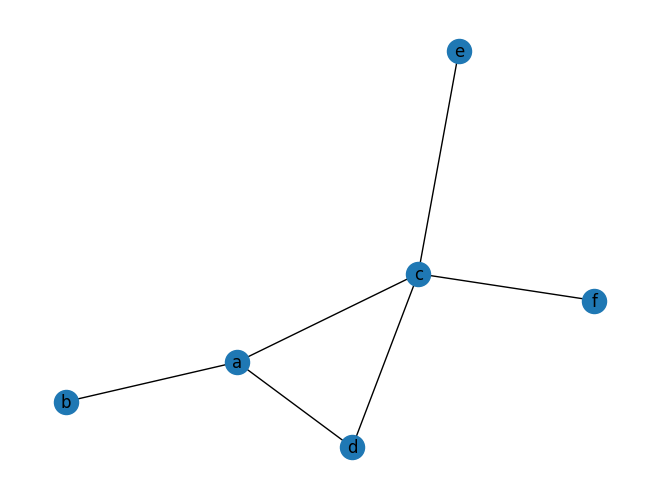

In [25]:
G = nx.Graph()

G.add_edge("a", "b")
G.add_edge("a", "c")
G.add_edge("c", "d")
G.add_edge("c", "e")
G.add_edge("c", "f")
G.add_edge("a", "d")

nx.draw(G, with_labels=True)

Can you plot a graph of Wikipedia links? Extend the bfs function by plotting a network. Limit the search to a reasonable number of nodes.

In [26]:
import matplotlib.pyplot as plt

def bfs_graph(start_url, max_nodes=15):
    """
    BFS crawler that builds a NetworkX graph of Wikipedia links.
    - start_url: starting Wikipedia URL
    - max_nodes: maximum number of nodes in the graph
    """
    visited = set()
    queue = deque([start_url])
    G = nx.Graph()  # initialize empty graph

    while queue and len(visited) < max_nodes:
        url = queue.popleft()
        if url in visited:
            continue

        try:
            response = requests.get(url, headers=headers)
            response.raise_for_status()
            visited.add(url)
            print(f"Visiting ({len(visited)}): {url}")

            parsed = bs4.BeautifulSoup(response.text, 'html.parser')
            links = parsed.find_all('a', href=re.compile(r'^/wiki/[^:#]*$'))
            random.shuffle(links)

            for link in links:
                full_url = "https://en.wikipedia.org" + link['href']
                if full_url not in visited:
                    queue.append(full_url)
                    # Add edge from current page to linked page
                    G.add_edge(url, full_url)

            sleep(random.random() * 2 + 1)  # polite delay

        except requests.RequestException as e:
            print(f"Error fetching {url}: {e}")

    # Plot the graph
    plt.figure(figsize=(12, 8))
    nx.draw(G, with_labels=False, node_size=500, node_color="skyblue", edge_color="gray")
    plt.title(f"Wikipedia Link Graph starting from {start_url}")
    plt.show()

    return G

Visiting (1): https://en.wikipedia.org/wiki/Pozna%C5%84_University_of_Technology
Visiting (2): https://en.wikipedia.org/wiki/Lublin_University_of_Technology
Visiting (3): https://en.wikipedia.org/wiki/Siedlce_University_of_Natural_Sciences_and_Humanities
Visiting (4): https://en.wikipedia.org/wiki/European_Credit_Transfer_System
Visiting (5): https://en.wikipedia.org/wiki/Pozna%C5%84_University_of_Economics_and_Business
Visiting (6): https://en.wikipedia.org/wiki/University_of_Warsaw
Visiting (7): https://en.wikipedia.org/wiki/Graz_University_of_Technology
Visiting (8): https://en.wikipedia.org/wiki/Polytechnic_University_of_Valencia
Visiting (9): https://en.wikipedia.org/wiki/Nicolaus_Copernicus_University_Ludwik_Rydygier_Collegium_Medicum_in_Bydgoszcz
Visiting (10): https://en.wikipedia.org/wiki/Kazimierz_Pu%C5%82aski_University_of_Technology_and_Humanities_in_Radom
Visiting (11): https://en.wikipedia.org/wiki/Andrzej_Jajszczyk
Visiting (12): https://en.wikipedia.org/wiki/Lund_Univer

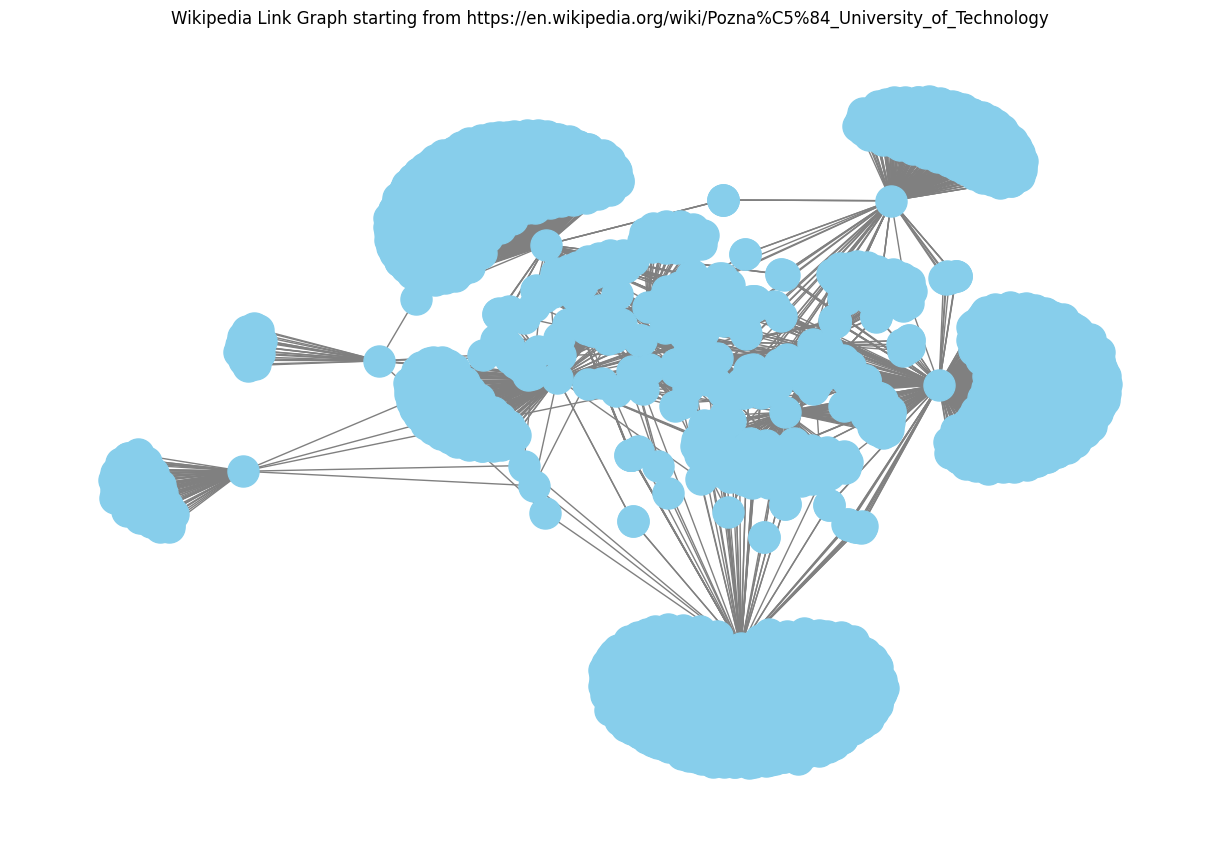

In [27]:
bfs_graph('https://en.wikipedia.org/wiki/Pozna%C5%84_University_of_Technology')

# Scrapy

Scrapy is an efficient library for web crawling and scraping. It has a slightly higher entrance level than requests + bs but it's much easier for complex tasks.

In [28]:
import requests
import bs4
import re
from time import sleep
import random

import scrapy
from scrapy.crawler import CrawlerProcess

In [29]:
class MySpider(scrapy.Spider):
    name = "lab1"

    start_urls = ['http://quotes.toscrape.com']

    def parse(self, response):
        quotes = response.css('div.quote')
        for quote in quotes: # you can extract data you need
            yield {
                'text': quote.css('.text::text').get(),
                'author': quote.css('.author::text').get(),
            }

        next_page = response.css('li.next a::attr(href)').get() #find next URL

        if next_page is not None:
            next_page = response.urljoin(next_page)
            yield scrapy.Request(next_page, callback=self.parse) #and process it

In [ ]:
process = CrawlerProcess({
    'USER_AGENT': 'Mozilla/4.0 (compatible; MSIE 7.0; Windows NT 5.1)'
})

process.crawl(MySpider)
process.start()

## Additional task

Which color of a car is the most expensive? Analyze offers from https://www.olx.pl/motoryzacja/samochody/ some of them leads to olx while other to otomoto. Can you use data from both sources?

In [30]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from collections import defaultdict
import re
import time

headers = {
    'User-Agent': 'IRclasses'
}

def clean_price(price_str):
    """Remove zł and 'do negocjacji', convert to integer"""
    if not price_str:
        return 0
    price_clean = re.sub(r"[^0-9]", "", price_str)
    return int(price_clean) if price_clean else 0

url = 'https://www.olx.pl/motoryzacja/samochody/'
response = requests.get(url, headers=headers)
parsed = BeautifulSoup(response.text, 'html.parser')

cards = parsed.find_all('div', attrs={'data-cy': 'l-card'})
cars_data = []

for card in cards:
    a_tag = card.find('a', href=True)
    if not a_tag:
        continue
    
    link = a_tag['href']

    # Get price from the card (if available)
    price_tag = card.find("p", {"data-testid": "ad-price"})
    price_raw = price_tag.text.strip() if price_tag else "0"
    price = clean_price(price_raw)

    color = "N/A"

    try:
        if "otomoto.pl" in link:
            resp_otomoto = requests.get(link, headers=headers)
            soup_otomoto = BeautifulSoup(resp_otomoto.text, 'html.parser')

            color_div = soup_otomoto.find("div", {"data-testid": "color"})
            if color_div:
                p_tags = color_div.find_all("p")
                if p_tags:
                    color = p_tags[-1].text.strip()

        else:
            if link.startswith("/"):
                link = "https://www.olx.pl" + link

            resp_olx = requests.get(link, headers=headers)
            soup_olx = BeautifulSoup(resp_olx.text, 'html.parser')

            params_div = soup_olx.find("div", {"data-testid": "ad-parameters-container"})
            if params_div:
                p_tags = params_div.find_all("p")
                for p in p_tags:
                    if "Kolor:" in p.text:
                        color = p.text.split("Kolor:")[-1].strip()
                        break

        cars_data.append({"price": price, "color": color})
        time.sleep(0.5)  # polite scraping delay

    except Exception as e:
        print(f"Failed to scrape page: {link}, Error: {e}")

df = pd.DataFrame(cars_data)
df = df.drop_duplicates().query("color != 'N/A'")
avg_price_per_color = df.groupby('color')['price'].mean().sort_values(ascending=False)
print("\nAverage price by color (most expensive first):")
print(avg_price_per_color.to_string(float_format='{:,.0f} zł'.format))



Average price by color (most expensive first):
color
Złoty              253,000 zł
Niebieski           85,260 zł
Biały               76,800 zł
Inny kolor          64,938 zł
Czarny              61,193 zł
Szary               60,994 zł
Brązowy – Beżowy    46,300 zł
Srebrny             26,909 zł
Zielony             15,450 zł


<details>

<summary>Bonus</summary>

Funny website for scraping https://web.archive.org/web/20190615072453/https://sirius.cs.put.poznan.pl/~inf66204/WKC.html
</details>